# Analiza czynników ryzyka choroby Alzheimera — projekt ML

Przewidywanie diagnozy choroby Alzheimera na podstawie danych demograficznych, stylu życia, historii medycznej i ocen kognitywnych.

[Alzheimer's Disease Dataset](https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset)

Logistic Regression, Decision Tree, Random Forest, i XGBoost (na dodatek dla testu; chciałam sprawdzić jak sobie jakiś nowy szybki model poradzi)

# 1. Importowanie bibliotek i wczytanie danych

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# !kaggle datasets download -d rabieelkharoua/alzheimers-disease-dataset --unzip

df = pd.read_csv('alzheimers_disease_data.csv')

print(f"Liczba wierszy (pacjentów): {df.shape[0]}")
print(f"Liczba kolumn (cech): {df.shape[1]}")

Liczba wierszy (pacjentów): 2149
Liczba kolumn (cech): 35


In [4]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

# 2. Czyszczenie danych

In [6]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

In [7]:
print(df['DoctorInCharge'].value_counts())

DoctorInCharge
XXXConfid    2149
Name: count, dtype: int64


In [8]:
df = df.drop(columns=['PatientID', 'DoctorInCharge'])

print(f'Po usunięciu: {df.shape[0]} wierszy, {df.shape[1]} kolumn')

Po usunięciu: 2149 wierszy, 33 kolumn


## Czyszczenie danych 

**Usunięte kolumny (2):**
- `PatientID` — identyfikator pacjenta
- `DoctorInCharge` — zakodowany lekarz

**Wynik:** 35 kolumn - 33 cechy predykcyjne + zmienna docelowa

In [9]:
zmienne_kat_wiel = ['Ethnicity', 'Gender', 'EducationLevel']

for col in zmienne_kat_wiel:
    df[col] = df[col].astype('category')

# Ethnicity, Gender i EducationLevel to zmienne kategoryczne — zmienilam dtype na category
# żeby select_dtypes poprawnie je rozpoznało i rozdzieliło od zmiennych numerycznych.

features = df.drop(columns=['Diagnosis'])

num_cols = features.select_dtypes(include=['number']).columns.tolist()
cat_cols = features.select_dtypes(exclude=['number']).columns.tolist()

In [10]:
# Statystyki opisowe zmiennych numerycznych (ciągłych)
print("ZMIENNE NUMERYCZNE — STATYSTYKI")
df[num_cols].describe().T

ZMIENNE NUMERYCZNE — STATYSTYKI


,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346
SleepQuality,2149.0,7.051081,1.763573,4.002629,5.482997,7.115646,8.562521,9.999840
FamilyHistoryAlzheimers,2149.0,0.252210,0.434382,0.000000,0.000000,0.000000,1.000000,1.000000
CardiovascularDisease,2149.0,0.144253,0.351428,0.000000,0.000000,0.000000,0.000000,1.000000
Diabetes,2149.0,0.150768,0.357906,0.000000,0.000000,0.000000,0.000000,1.000000


# 3. Analiza danych

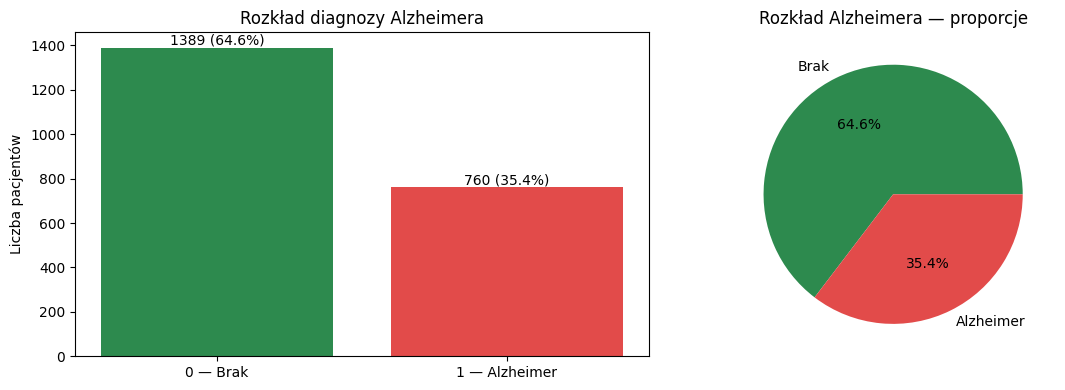

Nierównowaga klas: 1389 vs 760


In [11]:
# Rozkład zmiennej diagnosis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Diagnosis'].value_counts()
colors = ['#2D8A4E', '#E24B4A']

# Wykres słupkowy
axes[0].bar(['0 — Brak', '1 — Alzheimer'], counts.values, color=colors)

for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, f"{v} ({v/len(df)*100:.1f}%)", ha='center')

axes[0].set_title('Rozkład diagnozy Alzheimera')
axes[0].set_ylabel('Liczba pacjentów')

# Wykres kołowy
axes[1].pie(counts.values, labels=['Brak', 'Alzheimer'], colors=colors,
            autopct='%1.1f%%')
axes[1].set_title('Rozkład Alzheimera — proporcje')

plt.tight_layout()
plt.show()

print(f"Nierównowaga klas: {counts[0]} vs {counts[1]}")

## 3.1 Rozkład zmiennej diagnosis

Zbiór danych zawiera 64,7% przypadków bez choroby i 35,3% z Alzheimerem, czyli ma umiarkowaną nierównowagę klas, jest w miare ok.

Aby modele nie faworyzowały klasy większościowej (brak Alzheimera) zastosowalam tu parametr class_weight='balanced (lub scale_pos_weight w XGBoost), a oceniam przez F1-score więc bedzie wszystko sprawiedliwie w klasach


In [12]:
# Macierz korelacji Pearsona — używana w analizie korelacji z Diagnosis
corr_matrix = df.corr(numeric_only=True)

<Axes: >

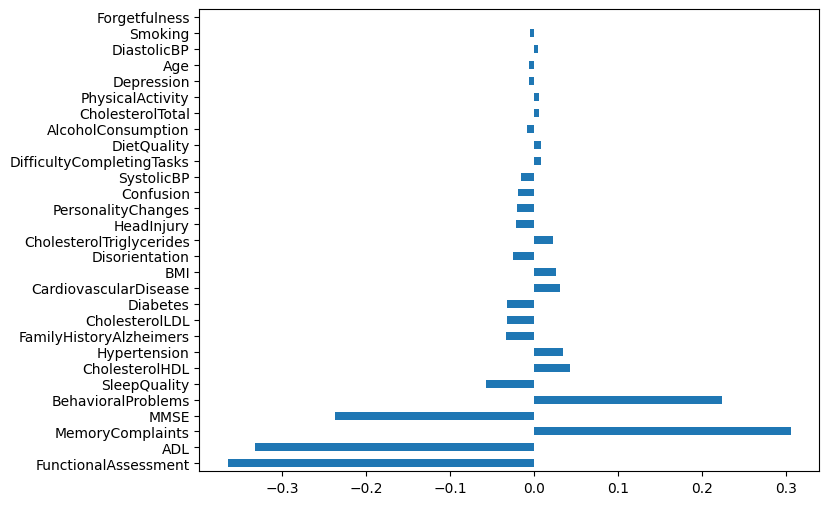

In [13]:
#Korelacje cech numerycznych z diagnosis
corr_with_target = corr_matrix['Diagnosis'].drop('Diagnosis').sort_values(key=abs, ascending=False)
corr_with_target.plot(kind='barh', figsize=(8, 6))

/var/folders/8l/07z8qb915t50m38y5bt85cjw0000gn/T/ipykernel_71866/1362106307.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)


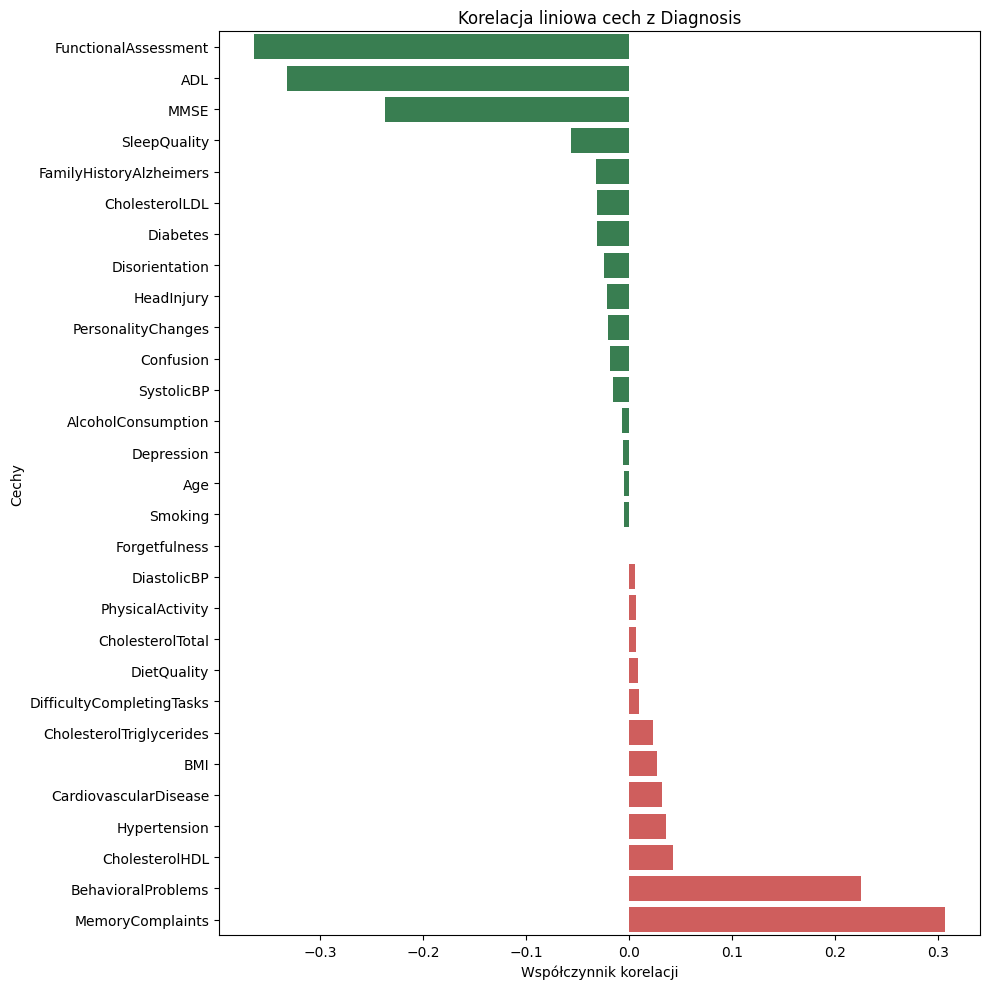

In [14]:
# Wykres słupkowy — korelacja cech z Diagnosis

# sortowanie rosnące
corr_with_target = corr_matrix['Diagnosis'].drop('Diagnosis').sort_values()
plt.figure(figsize=(10, 10))

colors = ['#2D8A4E' if x < 0 else '#E24B4A' for x in corr_with_target.values]

sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)

plt.title('Korelacja liniowa cech z Diagnosis')
plt.xlabel('Współczynnik korelacji')
plt.ylabel('Cechy')
plt.tight_layout()
plt.show()

## 3.2 Korelacja cech z diagnozą

Najsilniejsze korelacje z `Diagnosis` wykazują cechy testów kognitywnych (`MMSE`, `FunctionalAssessment`, `ADL`) oraz część symptomów (jak memory complaints), czyli mają najwyższą moc predykcyjną w zbiorze

(MMSE- Mini-Mental State Examination to test sprawnosci umyslowej, a ADL - Activities of Daily Living to ocena samodzielnego dbania o siebie)


## 3.3 Pełna macierz korelacji (heatmapa)

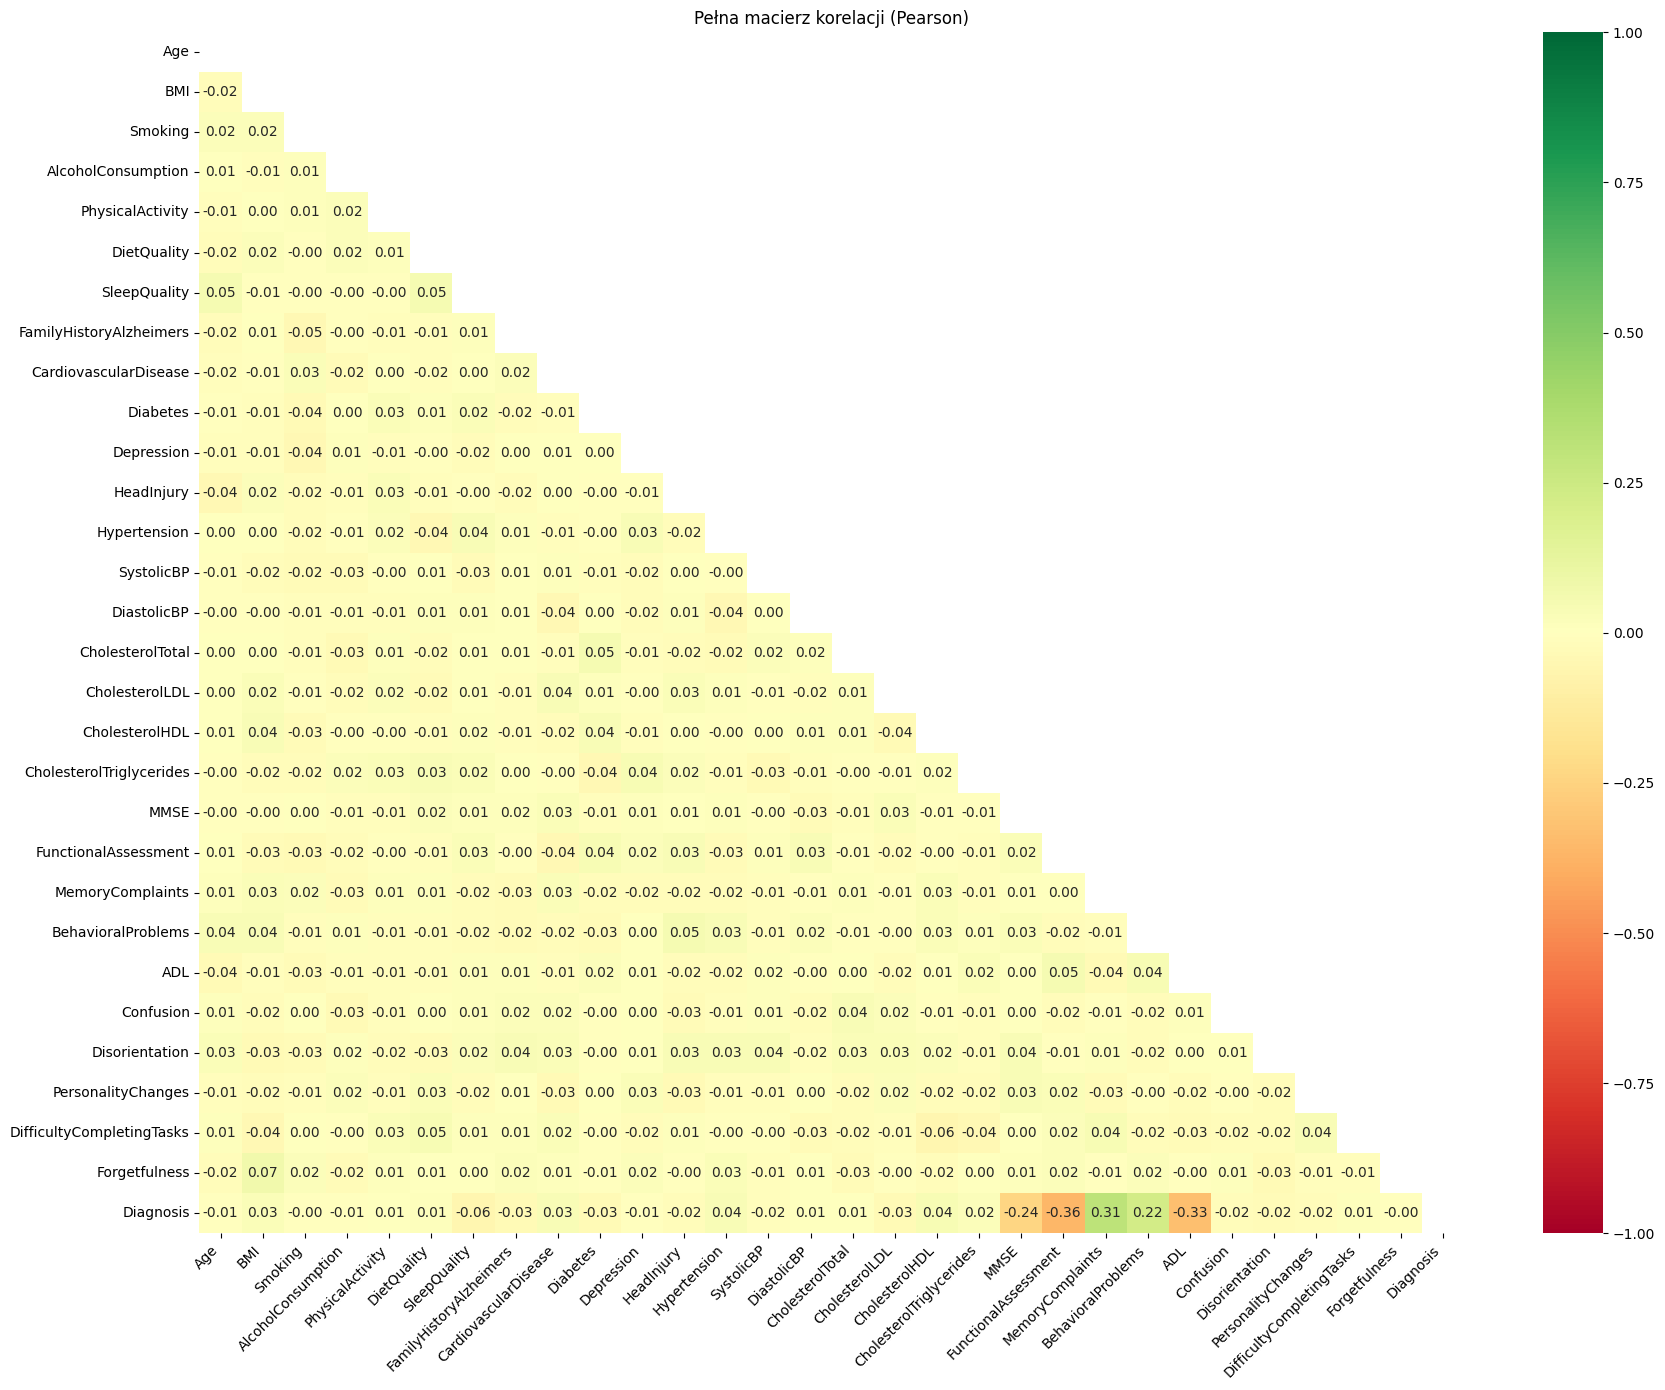

In [15]:
plt.figure(figsize=(18, 14))

corr_full = df.corr(numeric_only=True)

# np.triu tworzy macierz z True w górnym trójkącie (maska ukrywa duplikaty korelacji, zeby sie
#nie powtarzalo to pokazuje sie tylko dolny trojkat macierzy
mask = np.triu(np.ones_like(corr_full, dtype=bool))

sns.heatmap(
    corr_full, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn',   # czerwony (ujemna); żółty (zero); zielony (dodatnia)
    center=0,         # 0 to środek skali kolorów
    vmin=-1, vmax=1,  # korelacja Pearsona [-1, 1]
)
plt.title('Pełna macierz korelacji (Pearson)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.4 Boxploty kluczowych cech

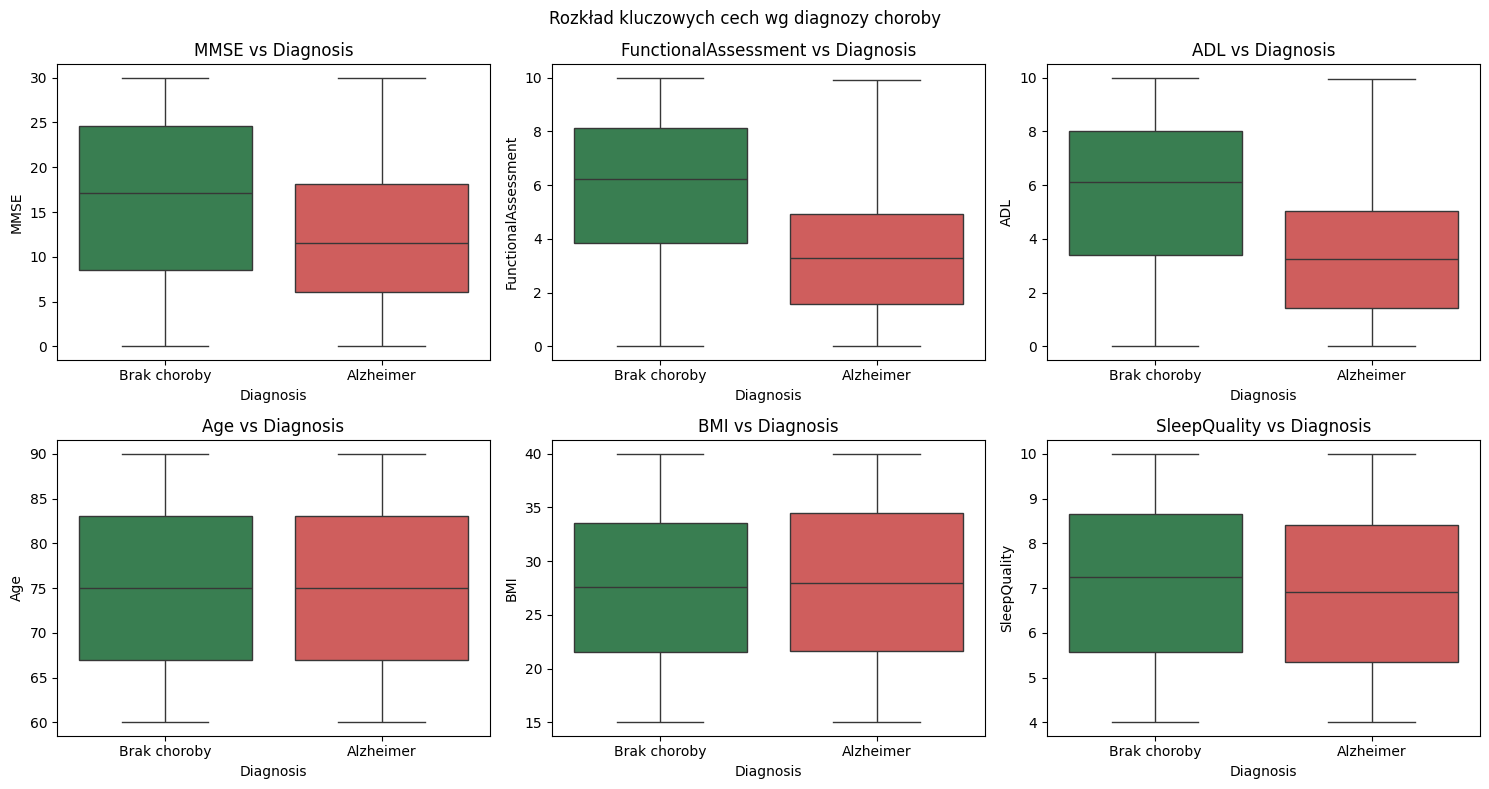

In [16]:
# Boxploty kluczowych cech vs Diagnosis
key_features = ['MMSE', 'FunctionalAssessment', 'ADL', 'Age', 'BMI', 'SleepQuality']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ravel() rozwija siatke sieci na prostą listę, zeby iterować po kolei
axes = axes.ravel()

for i, feat in enumerate(key_features):
    sns.boxplot(x='Diagnosis', y=feat, data=df, ax=axes[i],
                palette={0: '#2D8A4E', 1: '#E24B4A'}, hue='Diagnosis', legend=False)
    axes[i].set_title(f'{feat} vs Diagnosis')
    axes[i].set_xticks([0, 1], labels=['Brak choroby', 'Alzheimer'])

plt.suptitle('Rozkład kluczowych cech wg diagnozy choroby')
plt.tight_layout()
plt.show()

# 4. Podział danych na zbiór treningowy i testowy

In [17]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 67  
TEST_SIZE = 0.20   

X = df.drop(columns=['Diagnosis'])  # wszystko oprócz zmiennej docelowej
y = df['Diagnosis']               

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y #obie zmienne proporcjonalne
)

print(f"Rozmiar macierzy cech: {X.shape[0]} wierszy × {X.shape[1]} kolumn")
print(f"Zbiór treningowy: {X_train.shape[0]} pacjentów ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Zbiór testowy:    {X_test.shape[0]} pacjentów ({X_test.shape[0]/len(X)*100:.0f}%)")

Rozmiar macierzy cech: 2149 wierszy × 32 kolumn
Zbiór treningowy: 1719 pacjentów (80%)
Zbiór testowy:    430 pacjentów (20%)


# Hipoteza 1

Połączenie czynników ryzyka związanych ze stylem życia i historią medyczną pacjenta (BMI, aktywność fizyczna, jakość snu, choroby współistniejące) pozwala na skuteczniejszą klasyfikację niż tylko dane demograficzne (wiek, płeć, pochodzenie, wykształcenie).

**WERYFIKACJA:** model lifestyle+medyczny osiągnie macro F1-score o co najmniej 0.08 wyższy niż model demograficzny. Weryfikacja przeprowadzona na Logistic Regression i Random Forest.

In [18]:
features_demographic = ['Age', 'Gender', 'Ethnicity', 'EducationLevel']

features_lifestyle_medical = [
    'BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'Smoking', 'AlcoholConsumption',
    'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury',
    'Hypertension', 'FamilyHistoryAlzheimers'
]

X_demo_train = X_train[features_demographic]
X_demo_test  = X_test[features_demographic]
X_life_train = X_train[features_lifestyle_medical]
X_life_test  = X_test[features_lifestyle_medical]

print(f"Cechy demograficzne ({len(features_demographic)}): {features_demographic}")
print(f"Cechy lifestyle+med ({len(features_lifestyle_medical)}): {features_lifestyle_medical}")

Cechy demograficzne (4): ['Age', 'Gender', 'Ethnicity', 'EducationLevel']
Cechy lifestyle+med (12): ['BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'Smoking', 'AlcoholConsumption', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'FamilyHistoryAlzheimers']


In [19]:
# Logistic Regression z Pipeline (StandardScaler I LR)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score

pipe_lr_demo = Pipeline([
    ('scaler', StandardScaler()), 
    ('lr', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'))
])
pipe_lr_demo.fit(X_demo_train, y_train)
y_pred_lr_demo = pipe_lr_demo.predict(X_demo_test)
f1_lr_demo = f1_score(y_test, y_pred_lr_demo, average='macro')

pipe_lr_life = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'))
])
pipe_lr_life.fit(X_life_train, y_train)
y_pred_lr_life = pipe_lr_life.predict(X_life_test)
f1_lr_life = f1_score(y_test, y_pred_lr_life, average='macro')

print("HIPOTEZA 1 — LOGISTIC REGRESSION (Pipeline ze skalowaniem cech)")

print(f"\nModel DEMOGRAFICZNY")
print(classification_report(y_test, y_pred_lr_demo, target_names=['Brak choroby', 'Alzheimer']))
print(f"macro F1: {f1_lr_demo:.4f}")

print(f"\nModel LIFESTYLE+MEDYCZNY")
print(classification_report(y_test, y_pred_lr_life, target_names=['Brak choroby', 'Alzheimer']))
print(f"macro F1: {f1_lr_life:.4f}")

delta_lr = f1_lr_life - f1_lr_demo
print(f"Różnica (lifestyle - demograficzny): {delta_lr:+.4f}")

HIPOTEZA 1 — LOGISTIC REGRESSION (Pipeline ze skalowaniem cech)

Model DEMOGRAFICZNY
              precision    recall  f1-score   support

Brak choroby       0.69      0.50      0.58       278
   Alzheimer       0.39      0.59      0.47       152

    accuracy                           0.53       430
   macro avg       0.54      0.54      0.52       430
weighted avg       0.58      0.53      0.54       430

macro F1: 0.5243

Model LIFESTYLE+MEDYCZNY
              precision    recall  f1-score   support

Brak choroby       0.67      0.51      0.58       278
   Alzheimer       0.37      0.53      0.44       152

    accuracy                           0.52       430
   macro avg       0.52      0.52      0.51       430
weighted avg       0.56      0.52      0.53       430

macro F1: 0.5067
Różnica (lifestyle - demograficzny): -0.0176


In [20]:
# Random Forest porównanie
from sklearn.ensemble import RandomForestClassifier

rf_demo = RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, class_weight='balanced')
rf_demo.fit(X_demo_train, y_train)
y_pred_rf_demo = rf_demo.predict(X_demo_test)
f1_rf_demo = f1_score(y_test, y_pred_rf_demo, average='macro')

rf_life = RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, class_weight='balanced')
rf_life.fit(X_life_train, y_train)
y_pred_rf_life = rf_life.predict(X_life_test)
f1_rf_life = f1_score(y_test, y_pred_rf_life, average='macro')

print("HIPOTEZA 1 — RANDOM FOREST")
print(f"\nRF DEMOGRAFICZNY — macro F1: {f1_rf_demo:.4f}")
print(classification_report(y_test, y_pred_rf_demo, target_names=['Brak Choroby', 'Alzheimer']))

print(f"RF LIFESTYLE+MEDYCZNY — macro F1: {f1_rf_life:.4f}")
print(classification_report(y_test, y_pred_rf_life, target_names=['Brak Choroby', 'Alzheimer']))

delta_rf = f1_rf_life - f1_rf_demo
print(f"Różnica (lifestyle - demo): {delta_rf:+.4f}")

HIPOTEZA 1 — RANDOM FOREST

RF DEMOGRAFICZNY — macro F1: 0.4765
              precision    recall  f1-score   support

Brak Choroby       0.63      0.60      0.62       278
   Alzheimer       0.33      0.35      0.34       152

    accuracy                           0.51       430
   macro avg       0.48      0.48      0.48       430
weighted avg       0.52      0.51      0.52       430

RF LIFESTYLE+MEDYCZNY — macro F1: 0.4313
              precision    recall  f1-score   support

Brak Choroby       0.64      0.90      0.75       278
   Alzheimer       0.28      0.07      0.12       152

    accuracy                           0.61       430
   macro avg       0.46      0.49      0.43       430
weighted avg       0.51      0.61      0.52       430

Różnica (lifestyle - demo): -0.0452


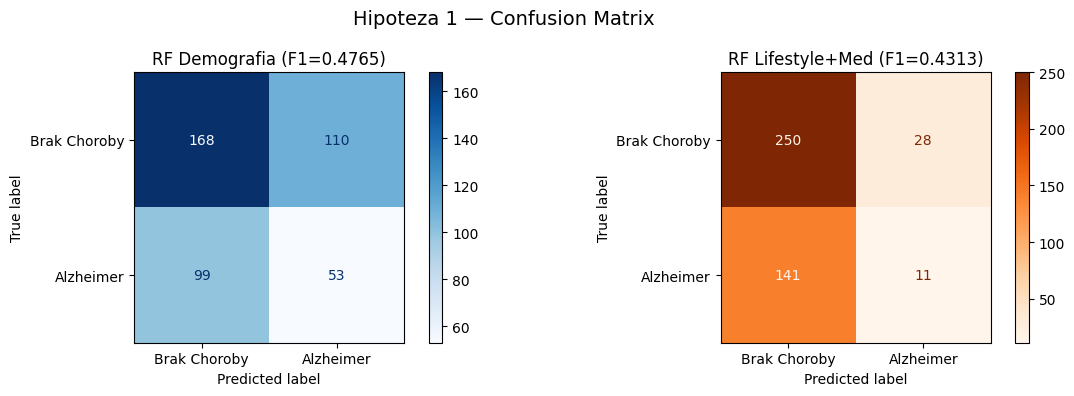

In [ ]:
#Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_demo,
    display_labels=['Brak Choroby', 'Alzheimer'], cmap='Blues', ax=axes[0])
axes[0].set_title(f'RF Demografia (F1={f1_rf_demo:.4f})')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_life,
    display_labels=['Brak Choroby', 'Alzheimer'], cmap='Oranges', ax=axes[1])
axes[1].set_title(f'RF Lifestyle+Med (F1={f1_rf_life:.4f})')

plt.suptitle('Hipoteza 1 — Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

Model demograficzny wykrył tylko 53 przypadki dobrze, a model ze stylem zycia tylko 11 przypadków dobrze- bardzo słabo; Niskie F1 obu modeli pokazuje, ze ani cechy demograficzne ani lifestylowe nie wystarczają

In [ ]:
# WNIOSEK Z H1
print("WNIOSEK — HIPOTEZA 1")
print(f"\nLR  demograficzny: macro F1 = {f1_lr_demo:.4f}")
print(f"LR  lifestyle+med: macro F1 = {f1_lr_life:.4f}")
print(f"RF  demograficzny: macro F1 = {f1_rf_demo:.4f}")
print(f"RF  lifestyle+med: macro F1 = {f1_rf_life:.4f}")

delta_lr  = f1_lr_life  - f1_lr_demo
delta_rf  = f1_rf_life  - f1_rf_demo
avg_delta = (delta_lr + delta_rf) / 2

if avg_delta >= 0.08:
    print(f"\nHIPOTEZA 1 POTWIERDZONA F1 ({avg_delta:+.4f}) >= 0.08.")
    print("Model lifestyle+medyczny skuteczniej klasyfikuje niż demograficzny.")
else:
    print(f"\nHIPOTEZA 1 OBALONA — model lifestyle+medyczny nie jest lepszy od demograficznego.")


WNIOSEK — HIPOTEZA 1

LR  demograficzny: macro F1 = 0.5243
LR  lifestyle+med: macro F1 = 0.5067
RF  demograficzny: macro F1 = 0.4765
RF  lifestyle+med: macro F1 = 0.4313

HIPOTEZA 1 OBALONA — model lifestyle+medyczny nie jest lepszy od demograficznego.


# Hipoteza 2

Wyniki profesjonalnych testów kognitywnych i funkcjonalnych (MMSE, FunctionalAssessment, ADL) stanowią kluczowe cechy dla modelu Random Forest. Ich wykluczenie ze zbioru treningowego obniży macro F1-score o co najmniej 0.10.

**WERYFIKACJA:** Random Forest z GridSearchCV na pełnym zbiorze, następnie ten sam algorytm bez trzech cech kognitywnych.



In [ ]:
# Random Forest + GridSearchCV + feature importance
from sklearn.model_selection import GridSearchCV

# Siatka hiperparametrów — GridSearch sprawdzi kazda kombinację 
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight='balanced'  # kompensuje nierównowagę 65%/35%
)

# cv=5 — 5-krotna walidacja krzyżowa; scoring='f1_macro' — optymalizacja macro F1
# n_jobs=-1 — szybciej
gs_rf = GridSearchCV(rf_base, param_grid_rf, cv=5, scoring='f1_macro',
                     n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)

print('Najlepsze hiperparametry RF:', gs_rf.best_params_)
print(f'Najlepszy CV macro F1 (train): {gs_rf.best_score_:.4f}')

# best_estimator_ — wytrenowany model z najlepszymi parametrami
rf_full = gs_rf.best_estimator_
y_pred_full = rf_full.predict(X_test)
f1_full = f1_score(y_test, y_pred_full, average='macro')

# feature_importances_ — tablica z wagami każdej cechy (suma = 1.0)
# Wyższa wartość = ważniejsza
importances = rf_full.feature_importances_

# Series z nazwami cech jako indeksem — łatwiej sortować i wyświetlać
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print('\nTOP 10 NAJWAŻNIEJSZYCH CECH — Random Forest (po GridSearchCV)')
for i, (feat, imp) in enumerate(feat_imp.head(10).items()):
    marker = ' KOGNITYWNA' if feat in ['MMSE', 'FunctionalAssessment', 'ADL'] else ''
    print(f'  {i+1:2d}. {feat:30s} {imp*100:5.2f}%{marker}')

print(f"\nŁączna waga top-3 cech kognitywnych: {feat_imp[['MMSE','FunctionalAssessment','ADL']].sum()*100:.1f}%")


Najlepsze hiperparametry RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Najlepszy CV macro F1 (train): 0.9397

TOP 10 NAJWAŻNIEJSZYCH CECH — Random Forest (po GridSearchCV)
   1. FunctionalAssessment           20.46% KOGNITYWNA
   2. ADL                            17.66% KOGNITYWNA
   3. MMSE                           14.58% KOGNITYWNA
   4. MemoryComplaints                8.55%
   5. BehavioralProblems              6.34%
   6. BMI                             2.47%
   7. PhysicalActivity                2.47%
   8. CholesterolHDL                  2.46%
   9. DietQuality                     2.46%
  10. CholesterolTriglycerides        2.42%

Łączna waga top-3 cech kognitywnych: 52.7%


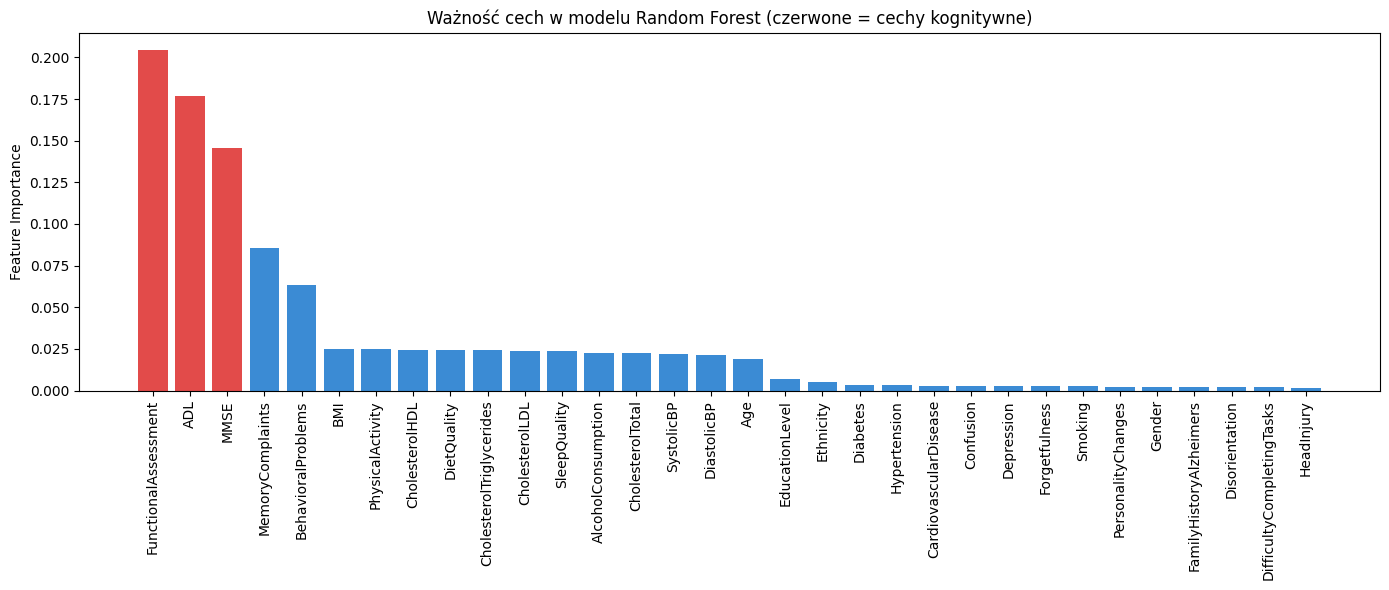

In [47]:
# H2: Wykres feature importance
fig, ax = plt.subplots(figsize=(14, 6))

colors_fi = ['#E24B4A' if f in ['MMSE', 'FunctionalAssessment', 'ADL'] else '#3B8BD4'
             for f in feat_imp.index]

ax.bar(range(len(feat_imp)), feat_imp.values, color=colors_fi)
ax.set_xticks(range(len(feat_imp)))
ax.set_xticklabels(feat_imp.index, rotation=90)
ax.set_ylabel('Feature Importance')
ax.set_title('Ważność cech w modelu Random Forest (czerwone = cechy kognitywne)')

plt.tight_layout()
plt.show()

In [ ]:
# model bez cech kognitywnych
features_to_remove = ['FunctionalAssessment', 'ADL', 'MMSE']

X_train_red_h2 = X_train.drop(columns=features_to_remove)
X_test_red_h2  = X_test.drop(columns=features_to_remove)

# Te same hiperparametry co model pełny (z GridSearchCV) — jedyną różnicą jest zbiór cech
rf_reduced = RandomForestClassifier(
    random_state=RANDOM_SEED,
    class_weight='balanced',
    **gs_rf.best_params_  # max_depth, n_estimators, min_samples_split z GridSearchCV
)
rf_reduced.fit(X_train_red_h2, y_train)
y_pred_reduced = rf_reduced.predict(X_test_red_h2)
f1_reduced = f1_score(y_test, y_pred_reduced, average='macro')

print("HIPOTEZA 2")
print(f"\nPełny model RF (wszystkie cechy) — macro F1: {f1_full:.4f}")
print(classification_report(y_test, y_pred_full, target_names=['Brak AD', 'Alzheimer']))

print(f"Okrojony model RF (bez MMSE/FA/ADL) — macro F1: {f1_reduced:.4f}")
print(classification_report(y_test, y_pred_reduced, target_names=['Brak AD', 'Alzheimer']))

spadek_h2 = f1_full - f1_reduced
print(f"Spadek macro F1 po usunięciu cech kognitywnych: {spadek_h2:.4f}")

HIPOTEZA 2

Pełny model RF (wszystkie cechy)     — macro F1: 0.9232
              precision    recall  f1-score   support

     Brak AD       0.94      0.95      0.95       278
   Alzheimer       0.91      0.89      0.90       152

    accuracy                           0.93       430
   macro avg       0.93      0.92      0.92       430
weighted avg       0.93      0.93      0.93       430

Okrojony model RF (bez MMSE/FA/ADL)  — macro F1: 0.6438
              precision    recall  f1-score   support

     Brak AD       0.74      0.79      0.76       278
   Alzheimer       0.56      0.49      0.52       152

    accuracy                           0.68       430
   macro avg       0.65      0.64      0.64       430
weighted avg       0.68      0.68      0.68       430

Spadek macro F1 po usunięciu cech kognitywnych: 0.2794


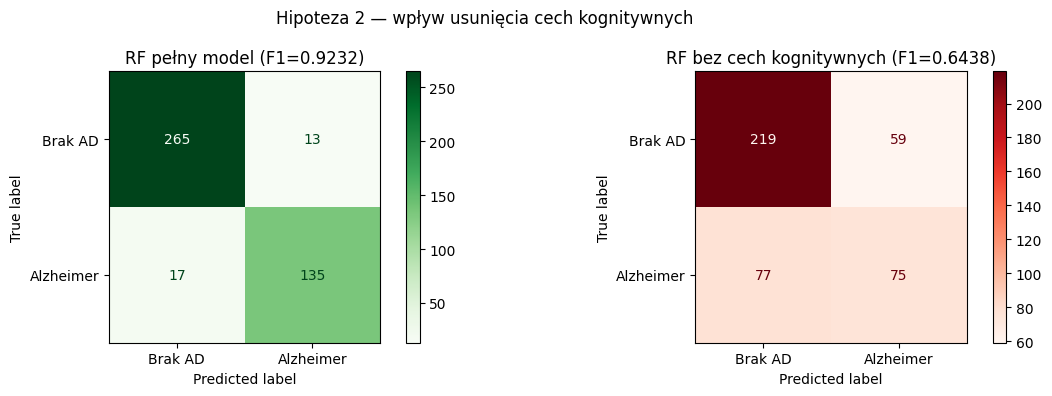

In [ ]:
#Confusion matrix — pełny vs okrojony
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_full,
    display_labels=['Brak AD', 'Alzheimer'], cmap='Greens', ax=axes[0])
axes[0].set_title(f'RF pełny model (F1={f1_full:.4f})')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_reduced,
    display_labels=['Brak AD', 'Alzheimer'], cmap='Reds', ax=axes[1])
axes[1].set_title(f'RF bez cech kognitywnych (F1={f1_reduced:.4f})')

plt.suptitle('Hipoteza 2 — wpływ usunięcia cech kognitywnych')
plt.tight_layout()
plt.show()

In [ ]:
# WNIOSEK Z H2
print("WNIOSEK — HIPOTEZA 2")
print(f"\nPełny model:    macro F1 = {f1_full:.4f}")
print(f"Okrojony model: macro F1 = {f1_reduced:.4f}")
print(f"Spadek:         {spadek_h2:.4f}")

if spadek_h2 >= 0.10:
    print(f"\nHIPOTEZA 2 POTWIERDZONA "
          f"— spadek F1 wynosi {spadek_h2:.4f}, co przekracza próg 0.10.")
    print("Cechy kognitywne (MMSE, FunctionalAssessment, ADL) są kluczowe dla predykcji.")
else:
    print(f"\nHIPOTEZA 2 OBALONA — spadek F1 wynosi {spadek_h2:.4f}, poniżej progu 0.10.")


WNIOSEK — HIPOTEZA 2

Pełny model:    macro F1 = 0.9232
Okrojony model: macro F1 = 0.6438
Spadek:         0.2794

HIPOTEZA 2 POTWIERDZONA — spadek F1 wynosi 0.2794, co przekracza próg 0.10.
Cechy kognitywne (MMSE, FunctionalAssessment, ADL) są kluczowe dla predykcji.


# Hipoteza 3 — Wykrywanie wczesnych symptomów

Samo występowanie wczesnych symptomów subiektywnych i behawioralnych (skargi na pamięć, zmiany osobowości, dezorientacja) zawiera wystarczające informacje, aby zidentyfikować pacjentów chorych z F1-score klasy Alzheimer na poziomie co najmniej **0.75**.

**WERYFIKACJA:** Decision Tree z GridSearchCV

In [ ]:
# Symptomy
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

symptoms_features = [
    'MemoryComplaints', 'BehavioralProblems', 'Confusion',
    'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

X_train_symptoms = X_train[symptoms_features]
X_test_symptoms  = X_test[symptoms_features]

print(f"Liczba cech symptomowych: {len(symptoms_features)}")
print(f"Cechy: {symptoms_features}")

Liczba cech symptomowych: 7
Cechy: ['MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']


In [ ]:
# GridSearch dla Decision Tree
# GridSearchCV sprawdza KAŻDĄ kombinację parametrów z param_grid 
param_grid = {
    'criterion': ['gini', 'entropy'],        # miara podziału węzła: indeks Gini lub entropia informacji
    'max_depth': [2, 3, 4, 5, 6, 7, None],  # maksymalna głębokość drzewa (None = bez limitu)
    'min_samples_split': [2, 5, 10, 20],     # minimalna liczba próbek do podziału węzła
    'min_samples_leaf': [1, 2, 4, 8]         # minimalna liczba próbek w liściu (zapobiega przeuczeniu)
}

dt_clf = DecisionTreeClassifier(random_state=RANDOM_SEED, class_weight='balanced')

grid_search = GridSearchCV(
    estimator=dt_clf,
    param_grid=param_grid,
    cv=5,              # 5-krotna walidacja krzyżowa (dane treningowe dzielone na 5 części)
    scoring='f1_macro',# kryterium wyboru: optymalizujemy macro F1, nie accuracy
    n_jobs=-1          # przyspiesza obliczenia
)
grid_search.fit(X_train_symptoms, y_train)

# best_estimator  model z najlepszymi parametrami
best_dt = grid_search.best_estimator_

print("HIPOTEZA 3 — GRID SEARCH DECISION TREE")
print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy CV macro F1: {grid_search.best_score_:.4f}")

HIPOTEZA 3 — GRID SEARCH DECISION TREE
Najlepsze parametry: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Najlepszy CV macro F1: 0.6882


In [ ]:
# wyniki na zbiorze testowym
y_pred_symptoms = best_dt.predict(X_test_symptoms)
f1_symptoms = f1_score(y_test, y_pred_symptoms, average='macro')

print("HIPOTEZA 3 — WYNIKI NA ZBIORZE TESTOWYM")
print(f"\nmacro F1-score: {f1_symptoms:.4f}")
print(classification_report(y_test, y_pred_symptoms, target_names=['Brak AD', 'Alzheimer']))

HIPOTEZA 3 — WYNIKI NA ZBIORZE TESTOWYM

macro F1-score: 0.6785
              precision    recall  f1-score   support

     Brak AD       0.77      0.78      0.77       278
   Alzheimer       0.59      0.58      0.58       152

    accuracy                           0.71       430
   macro avg       0.68      0.68      0.68       430
weighted avg       0.71      0.71      0.71       430



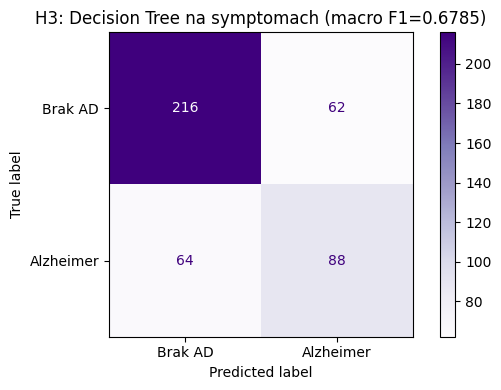

In [ ]:
#Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_symptoms,
    display_labels=['Brak AD', 'Alzheimer'], cmap='Purples', ax=ax)
ax.set_title(f'H3: Decision Tree na symptomach (macro F1={f1_symptoms:.4f})')
plt.tight_layout()
plt.show()

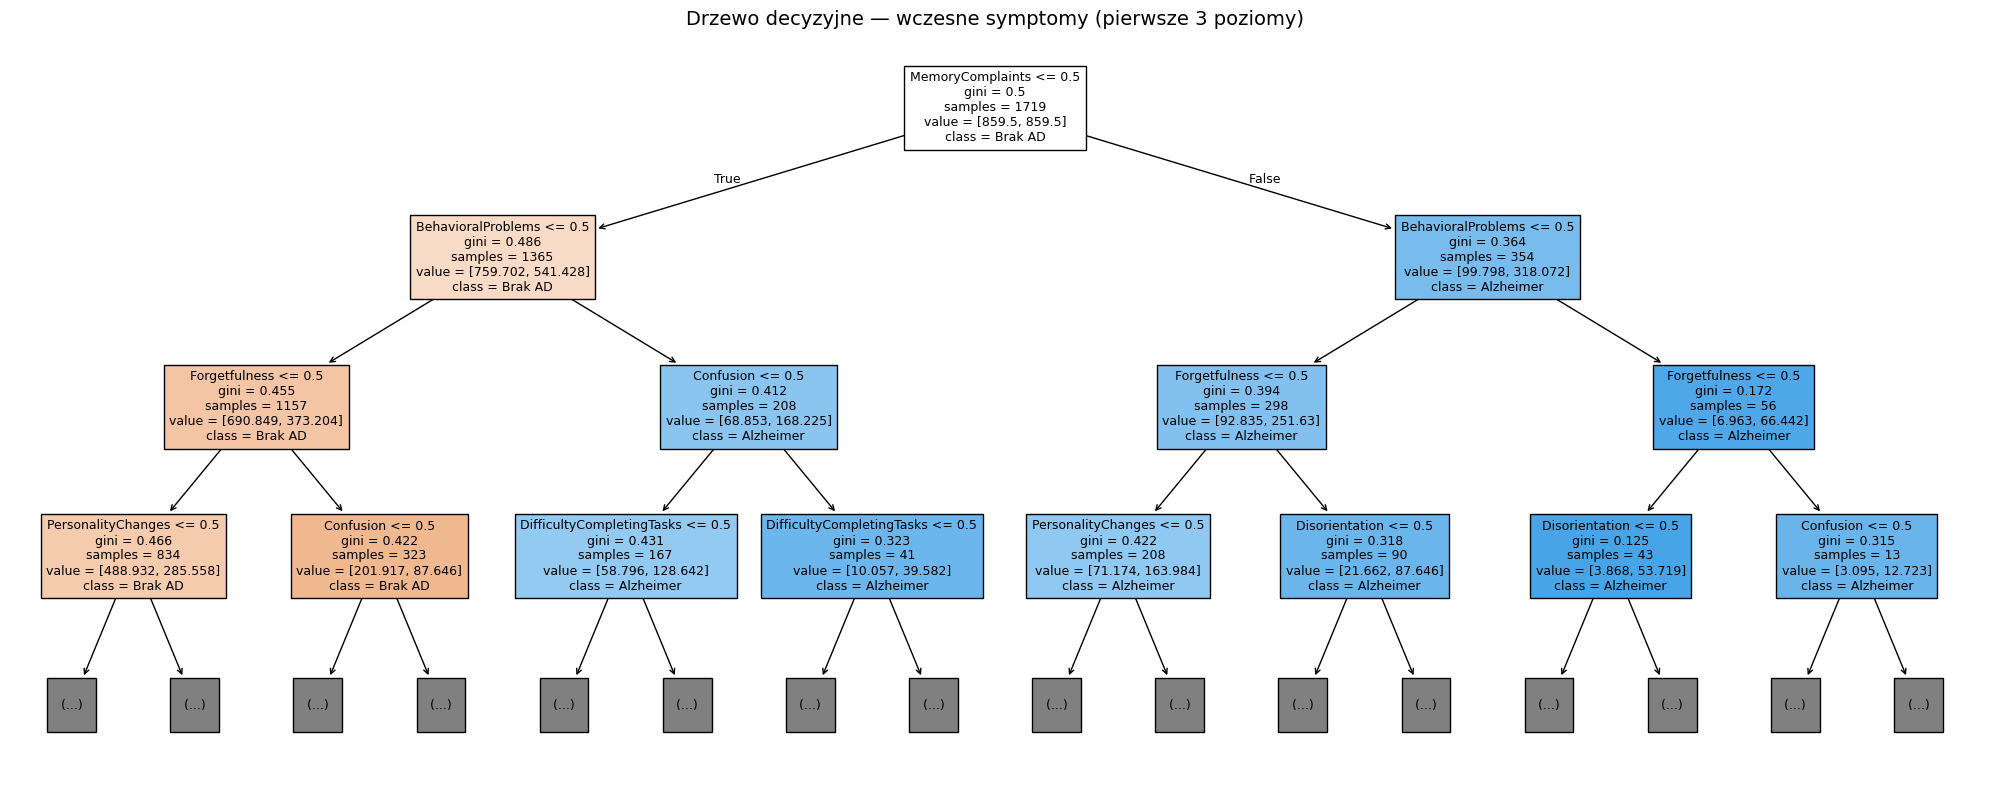

In [45]:
#Wizualizacja drzewa decyzyjnego
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=symptoms_features, class_names=['Brak AD', 'Alzheimer'],
          filled=True, fontsize=9, max_depth=3)
plt.title('Drzewo decyzyjne — wczesne symptomy (pierwsze 3 poziomy)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# WNIOSEK Z H3
from sklearn.metrics import recall_score

recall_class1 = recall_score(y_test, y_pred_symptoms, pos_label=1)
f1_class1 = f1_score(y_test, y_pred_symptoms, pos_label=1)

print("WNIOSEK — HIPOTEZA 3")
print(f"\nF1-score klasy Alzheimer:{f1_class1:.4f}")
print(f"Recall klasy Alzheimer: {recall_class1:.4f}")
print(f"Macro F1-score: {f1_symptoms:.4f}")

if f1_class1 >= 0.75:
    print(f"\nHIPOTEZA 3 POTWIERDZONA — F1 klasy Alzheimer wynosi {f1_class1:.4f} (próg: 0.75).")
else:
    print(f"\nHIPOTEZA 3 OBALONA — F1 klasy Alzheimer wynosi {f1_class1:.4f}, poniżej progu 0.75.")


WNIOSEK — HIPOTEZA 3

F1-score klasy Alzheimer: 0.5828
Recall klasy Alzheimer:   0.5789
Macro F1-score:           0.6785

HIPOTEZA 3 OBALONA — F1 klasy Alzheimer wynosi 0.5828, poniżej progu 0.75.


# Hipoteza 4 — XGBoost i analiza SHAP DODATEK JAKO TEST

(Chciałam sprawdzić na tej bazie jakis nowy bardzo dobry model, czy będzie kręcił lepsze wyniki.)

Hipoteza; XGBoost po RandomizedSearchCV osiągnie macro F1-score wyższy niż najlepszy model klasyczny (RF pełny z H2). SHAP pozwoli wskazać, które cechy mają największy wpływ na predykcję.

XGBoost buduje drzewa sekwencyjnie (gradient boosting) i może lepiej modelować trudne przypadki graniczne niż RF

In [34]:
# Instalacja dodatkowych bibliotek 
# %pip install xgboost shap -q

In [35]:
# XGBoost wymaga kolumn numerycznych — category z powrotem na int
cat_cols_encode = ['Gender', 'Ethnicity', 'EducationLevel']
X_train = X_train.copy()
X_test  = X_test.copy()
for col in cat_cols_encode:
    X_train[col] = X_train[col].cat.codes
    X_test[col]  = X_test[col].cat.codes

print('Kodowanie zakończone. Dtypes po zmianie:')
print(X_train[cat_cols_encode].dtypes)

Kodowanie zakończone. Dtypes po zmianie:
Gender            int8
Ethnicity         int8
EducationLevel    int8
dtype: object


In [36]:
# H4: XGBoost + RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform  # rozkłady do losowego próbkowania hiperparametrów

# scale_pos_weight wyrównuje nierównowagę klas w XGBoost
# Wzór: liczba próbek klasy 0 / liczba próbek klasy 1
# XGBoost daje większą "karę" za błędne klasyfikacje rzadszej klasy (Alzheimer)
scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight = {scale_pos:.2f} (stosunek klas w zbiorze treningowym)")

xgb_clf = XGBClassifier(
    random_state=RANDOM_SEED,
    eval_metric='logloss',   # funkcja straty do oceny podczas treningu
    scale_pos_weight=scale_pos,
    enable_categorical=True   # obsługa kolumn dtype=category
)

# RandomizedSearchCV losuje n_iter kombinacji zamiast sprawdzać wszystkie — szybsze niż GridSearchCV
# randint(a, b) — losuje całkowitą liczbę z zakresu [a, b)
# uniform(loc, scale) — losuje liczbę rzeczywistą z zakresu [loc, loc+scale]
param_distributions = {
    'n_estimators': randint(100, 500),        # liczba drzew (boosting rounds)
    'max_depth': randint(3, 10),              # głębokość pojedynczego drzewa
    'learning_rate': uniform(0.01, 0.3),      # współczynnik uczenia (krok gradientu)
    'subsample': uniform(0.6, 0.4),           # ułamek próbek do treningu każdego drzewa
    'colsample_bytree': uniform(0.6, 0.4),    # ułamek cech losowanych dla każdego drzewa
    'min_child_weight': randint(1, 10),       # minimalna suma wag w liściu (regularyzacja)
    'gamma': uniform(0, 0.5)                  # minimalna redukcja straty do dalszego podziału
}

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_distributions,
    n_iter=50, # liczba losowanych kombinacji (tu: 50 z miliardów możliwych)
    cv=5,# 5-krotna walidacja krzyżowa
    scoring='f1_macro',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0
)
random_search.fit(X_train, y_train)

# best_estimator_ — najlepszy model znaleziony przez przeszukiwanie
best_xgb = random_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

print("HIPOTEZA 4 — XGBoost")
print(f"\nNajlepsze parametry: {random_search.best_params_}")
print(f"CV macro F1: {random_search.best_score_:.4f}")
print(f"Test macro F1: {f1_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Brak AD', 'Alzheimer']))

scale_pos_weight = 1.83 (stosunek klas w zbiorze treningowym)
HIPOTEZA 4 — XGBoost

Najlepsze parametry: {'colsample_bytree': np.float64(0.7638354039473789), 'gamma': np.float64(0.2061272257629838), 'learning_rate': np.float64(0.022956631268929606), 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 392, 'subsample': np.float64(0.8696500218892482)}
CV macro F1: 0.9467
Test macro F1: 0.9341
              precision    recall  f1-score   support

     Brak AD       0.96      0.95      0.95       278
   Alzheimer       0.91      0.92      0.92       152

    accuracy                           0.94       430
   macro avg       0.93      0.94      0.93       430
weighted avg       0.94      0.94      0.94       430



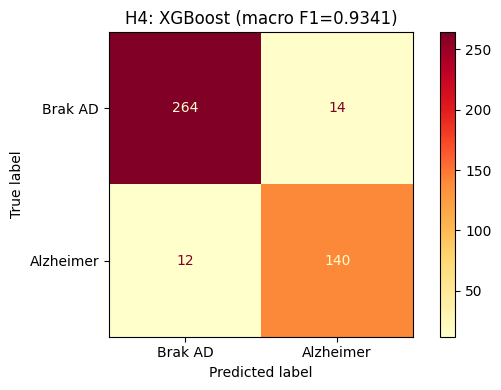

In [ ]:
#Confusion matrix XGBoost
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
    display_labels=['Brak AD', 'Alzheimer'], cmap='YlOrRd', ax=ax)
ax.set_title(f'H4: XGBoost (macro F1={f1_xgb:.4f})')
plt.tight_layout()
plt.show()

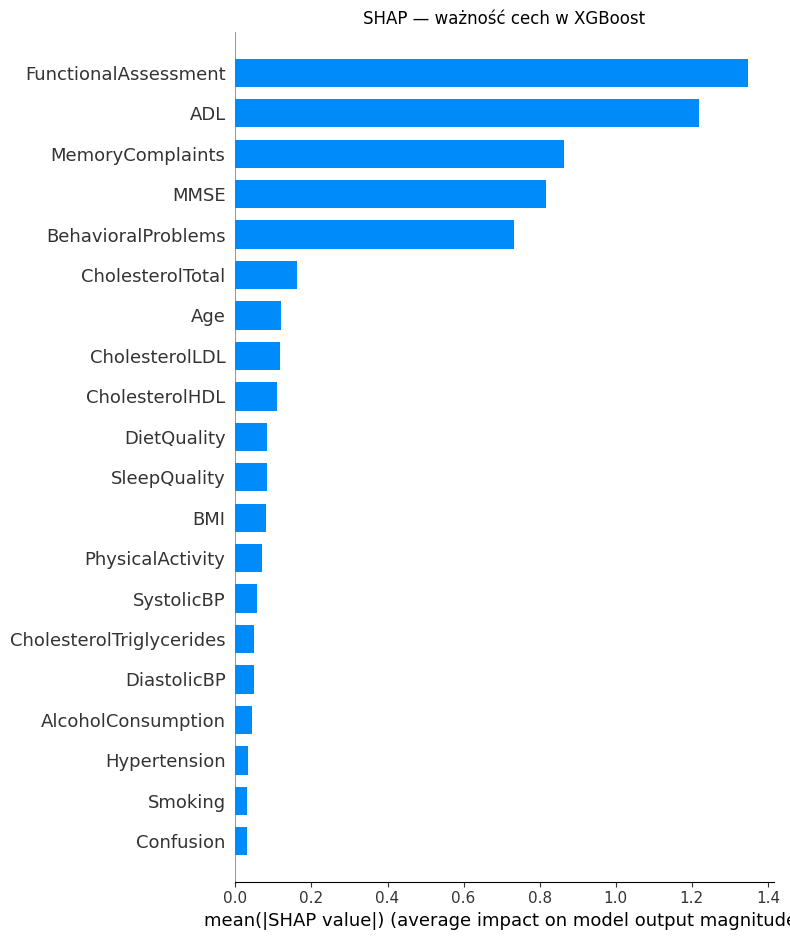

In [48]:
# H4: SHAP — wyjaśnialność modelu (SHapley Additive exPlanations)
# SHAP wyjaśnia DLACZEGO model podjął daną decyzję — ile każda cecha "dołożyła" do predykcji
import shap

# zoptymalizowany explainer
explainer = shap.TreeExplainer(best_xgb)

# shap_values — macierz o kształcie (n_próbek × n_cech)
# Każda wartość = wpływ danej cechy na predykcję dla konkretnego pacjenta
# Wartość dodatnia = cecha "pchała" model w stronę klasy 1 (Alzheimer)
# Wartość ujemna = cecha "pchała" model w stronę klasy 0 (brak choroby)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
# plot_type='bar' — uśredniona ważność bezwzględna (podobna do feature_importance, ale dokładniejsza)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP — ważność cech w XGBoost')
plt.tight_layout()
plt.show()

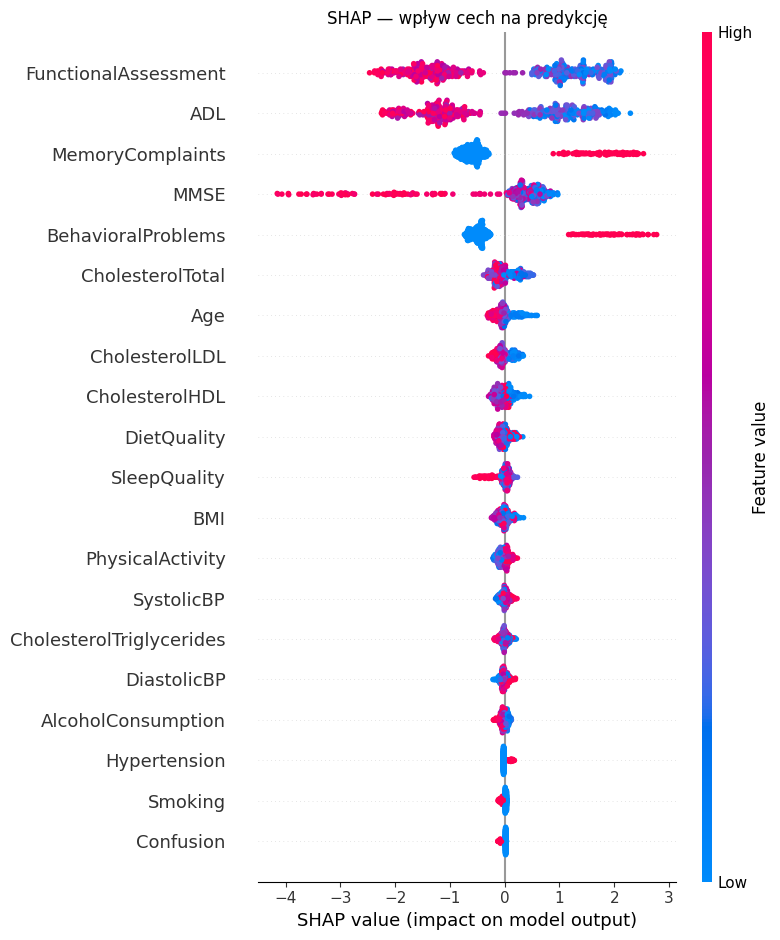

In [39]:
# H4: SHAP — bee swarm plot (wpływ wartości cechy na predykcję)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP — wpływ cech na predykcję')
plt.tight_layout()
plt.show()

In [ ]:
#WNIOSKI Z H4
print("WNIOSEK — HIPOTEZA 4")
print(f"\nNajlepszy model klasyczny (RF, GridSearchCV): macro F1 = {f1_full:.4f}")
print(f"XGBoost (RandomizedSearchCV): macro F1 = {f1_xgb:.4f}")

delta_h4 = f1_xgb - f1_full

if delta_h4 >= 0.05:
    print(f"\nHIPOTEZA 4 POTWIERDZONA — XGBoost lepszy o {delta_h4:.4f} (próg: 0.05).")
elif delta_h4 > 0:
    print(f"\nHIPOTEZA 4 CZĘŚCIOWO POTWIERDZONA — XGBoost lepszy o {delta_h4:.4f}, ale poniżej progu 0.05.")
else:
    print(f"\nHIPOTEZA 4 OBALONA — XGBoost nie pobł RF (różnica: {delta_h4:.4f}).")


WNIOSEK — HIPOTEZA 4

Najlepszy model klasyczny (RF, GridSearchCV): macro F1 = 0.9232
XGBoost (RandomizedSearchCV): macro F1 = 0.9341

HIPOTEZA 4 CZĘŚCIOWO POTWIERDZONA — XGBoost lepszy o 0.0108, ale poniżej progu 0.05.


### H4b — XGBoost bez cech kognitywnych

Dodatkowe sprawdzenie: czy XGBoost, pozbawiony kluczowych trzech cech kognitywnych co RF w H2, osiągnie lepszy wynik- czy przewaga boostingu utrzymuje się również przy ograniczonym zbiorze cech

In [41]:
#XGBoost bez cech kognitywnych
features_to_remove = ['FunctionalAssessment', 'ADL', 'MMSE']

# Tworzymy osobne kopie danych bez trzech cech kognitywnych
X_train_red_h4b = X_train.drop(columns=features_to_remove)
X_test_red_h4b  = X_test.drop(columns=features_to_remove)

# ** (double-asterisk) rozpakowuje słownik jako argumenty nazwane funkcji
# Dzięki temu używamy TYCH SAMYCH hiperparametrów co najlepszy model z H4 — uczciwe porównanie
xgb_reduced = XGBClassifier(
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    scale_pos_weight=scale_pos,
    enable_categorical=True,  # obsługa kolumn dtype=category
    **{k: v for k, v in random_search.best_params_.items()}
)
xgb_reduced.fit(X_train_red_h4b, y_train)
y_pred_xgb_reduced = xgb_reduced.predict(X_test_red_h4b)
f1_xgb_reduced = f1_score(y_test, y_pred_xgb_reduced, average='macro')

print('H4b — XGBoost BEZ CECH KOGNITYWNYCH')
print(classification_report(y_test, y_pred_xgb_reduced, target_names=['Brak AD', 'Alzheimer']))
print(f'XGBoost pelny:             macro F1 = {f1_xgb:.4f}')
print(f'XGBoost bez kognitywnych:  macro F1 = {f1_xgb_reduced:.4f}')
print(f'RF bez kognitywnych (H2):  macro F1 = {f1_reduced:.4f}')
print(f'\nSpadek XGBoost po ablacji:  {f1_xgb - f1_xgb_reduced:.4f}')
print(f'XGBoost vs RF (bez kogn.): {f1_xgb_reduced - f1_reduced:+.4f}')

H4b — XGBoost BEZ CECH KOGNITYWNYCH
              precision    recall  f1-score   support

     Brak AD       0.75      0.75      0.75       278
   Alzheimer       0.55      0.55      0.55       152

    accuracy                           0.68       430
   macro avg       0.65      0.65      0.65       430
weighted avg       0.68      0.68      0.68       430

XGBoost pelny:             macro F1 = 0.9341
XGBoost bez kognitywnych:  macro F1 = 0.6489
RF bez kognitywnych (H2):  macro F1 = 0.6438

Spadek XGBoost po ablacji:  0.2851
XGBoost vs RF (bez kogn.): +0.0052


# Podsumowanie — porównanie wszystkich modeli

In [42]:
# Tabela zbiorcza — WSZYSTKIE wyniki z ZMIENNYCH
results = pd.DataFrame({
    'Model': [
        'LR — Demografia (H1)',
        'LR — Lifestyle+Med (H1)',
        'RF — Demografia (H1)',
        'RF — Lifestyle+Med (H1)',
        'RF — Pełny model (H2)',
        'RF — Bez cech kogn. (H2)',
        'DT — Symptomy (H3)',
        'XGBoost — Pełny (H4)',
        'XGBoost — Bez kogn. (H4b)'
    ],
    'Cechy': [
        f'{len(features_demographic)} demogr.',
        f'{len(features_lifestyle_medical)} life+med',
        f'{len(features_demographic)} demogr.',
        f'{len(features_lifestyle_medical)} life+med',
        f'{X.shape[1]} wszystkie',
        f'{X.shape[1]-3} bez kogn.',
        f'{len(symptoms_features)} symptomy',
        f'{X.shape[1]} wszystkie',
        f'{X.shape[1]-3} bez kogn.'
    ],
    'Macro F1': [
        f1_lr_demo, f1_lr_life,
        f1_rf_demo, f1_rf_life,
        f1_full, f1_reduced,
        f1_symptoms, f1_xgb,
        f1_xgb_reduced
    ]
})

# sortowanie malejaco po F1, reset indeks od 0, potem przesuwa sie o 1 (ranking od 1)
results = results.sort_values('Macro F1', ascending=False).reset_index(drop=True)
results.index = results.index + 1
results.index.name = 'Rank'

print("RANKING WSZYSTKICH MODELI")
print(results.to_string())

# iloc[0] — pierwszy wiersz (najlepszy model po posortowaniu)
best_model_name = results.iloc[0]['Model']
best_f1 = results.iloc[0]['Macro F1']
print(f"\nNajlepszy model: {best_model_name} (macro F1 = {best_f1:.4f})")

RANKING WSZYSTKICH MODELI
                          Model         Cechy  Macro F1
Rank                                                   
1          XGBoost — Pełny (H4)  32 wszystkie  0.934051
2         RF — Pełny model (H2)  32 wszystkie  0.923214
3            DT — Symptomy (H3)    7 symptomy  0.678488
4     XGBoost — Bez kogn. (H4b)  29 bez kogn.  0.648926
5      RF — Bez cech kogn. (H2)  29 bez kogn.  0.643771
6          LR — Demografia (H1)     4 demogr.  0.524305
7       LR — Lifestyle+Med (H1)   12 life+med  0.506674
8          RF — Demografia (H1)     4 demogr.  0.476511
9       RF — Lifestyle+Med (H1)   12 life+med  0.431284

Najlepszy model: XGBoost — Pełny (H4) (macro F1 = 0.9341)


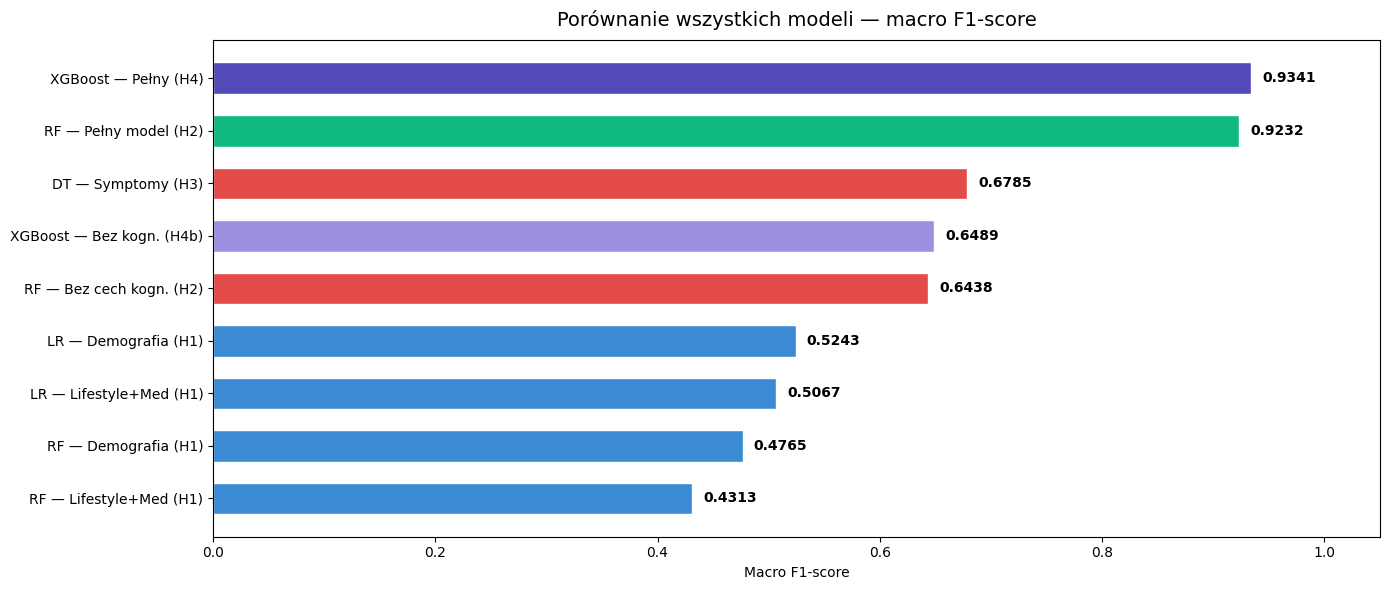

In [43]:
# Wykres porównawczy
fig, ax = plt.subplots(figsize=(14, 6))

models_sorted = results['Model'].values[::-1]
scores_sorted = results['Macro F1'].values[::-1]

colors_bar = []
for m in models_sorted:
    if 'XGBoost — Bez' in m:
        colors_bar.append('#9B8FE0')  # jasny fiolet — XGBoost bez cech kognitywnych
    elif 'XGBoost' in m:
        colors_bar.append('#534AB7')  # ciemny fiolet — XGBoost pełny
    elif 'Pełny' in m:
        colors_bar.append('#10b981')  # zielony — RF pełny
    elif 'Bez cech' in m or 'Bez kogn' in m or 'Symptomy' in m:
        colors_bar.append('#E24B4A')  # czerwony — modele okrojone / słabsze
    else:
        colors_bar.append('#3B8BD4')  # niebieski — pozostałe (LR, RF demo/life)

bars = ax.barh(range(len(models_sorted)), scores_sorted, color=colors_bar, edgecolor='white', height=0.6)

#etykiety z wartością F1 na końcu każdego słupka
for bar, score in zip(bars, scores_sorted):
    # get_y() + get_height()/2 — środek wysokości słupka (wyśrodkowanie etykiety w pionie)
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontweight='bold', fontsize=10)

ax.set_yticks(range(len(models_sorted)))
ax.set_yticklabels(models_sorted, fontsize=10)
ax.set_xlabel('Macro F1-score')
ax.set_title('Porównanie wszystkich modeli — macro F1-score', fontsize=14, pad=10)
ax.set_xlim(0, 1.05)


plt.tight_layout()
plt.show()

# Wnioski końcowe

**H1 — Cechy stylu życia vs demograficzne.** Hipoteza obalona.
Żaden z testowanych podzbiorów — ani demograficzny, ani lifestyle+medyczny — nie zawiera predyktorów kognitywnych (MMSE, ADL, FunctionalAssessment), które niosą zasadniczy sygnał diagnostyczny. Oba podzbiory osiągają zbliżone, niskie wyniki (macro F1 ok. 0.50–0.55). Cechy demograficzne okazały się tak samo słabe co cechy stylu życia **(co jest bardzo dziwne, myślałam ze cechy stylu zycia będą mialy wiekszy wplyw)** Bez danych kognitywnych przewidywanie Alzheimera jest istotnie ograniczone przez brak kluczowego sygnału.

**H2 — Rola cech kognitywnych.** Hipoteza potwierdzona.
Cechy MMSE, FunctionalAssessment i ADL odpowiadają łącznie za ok. 52.7% ważności cech w modelu Random Forest. Usunięcie tych trzech zmiennych obniża macro F1 z 0.9232 do 0.6438 (spadek 0.2794> 0.10). Wynik wskazuje, że żadna kombinacja pozostałych cech nie zastępuje profesjonalnej oceny kognitywnej w predykcji Alzheimera.

**H3 — Wczesne symptomy behawioralne.** Hipoteza obalona.
Decision Tree z GridSearchCV, trenowany wyłącznie na 7 binarnych symptomach, osiągnął F1-score klasy Alzheimer równy 0.5828 — poniżej wymaganego progu 0.75. Model nie wykrywa 42% chorych pacjentów

**H4 — XGBoost po RandomizedSearchCV.** Hipoteza częściowo potwierdzona.
XGBoost osiągnął macro F1 = 0.9341 wobec 0.9232 dla Random Forest po GridSearchCV (różnica 0.0108, poniżej progu 0.05). Analiza SHAP potwierdziła, że w obu modelach dominującymi predyktorami są te same trzy cechy kognitywne. Przewaga boostingu nad baggingiem jest, ale na moim zbiorze danych pozostaje niewielka (szkoda)

Ale co wazne to RF przeszukiwal 18 kombunacji w GridSearch a XGBoost 50 w RandomizedSearch wiec dlatego moglo miec przewage a nie z powodu boostingu.. Szczerze nie wiem ale myśle ze bardzo ciekawe i na pewno to zweryfikuje w kolejnym projekcie.

**H4b — XGBoost bez cech kognitywnych.**
Bylam ciekawa jak XGBoost sobie poradzi po usunięciu kluczowych cech (behawioralnych). Było lepiej ale spodziewałam się lepszych wyników. Po usunięciu wynik spada do macro F1 ok. 0.65 (róznica o 0.28), co dodatkowo potwierdza wniosek z H2. 


**Najlepszy model:** XGBoost pełny (macro F1 = 0.9341), przed Random Forest po GridSearchCV (0.9232). Oba wymagają wyników testów kognitywnych (MMSE, ADL, FunctionalAssessment). Są one najwazniejsze w tym zbiorze do predykcji choroby.

Ogólnie uwazam ze słaba baza danych (skoro predykcja Alzheimera wg. płci i innych cech demograficznych nie była gorsza od cech stylu zycia). Chciałam coś naukowego tutaj dowieść stąd baza medyczna ale nie wyszło